# Offline activities code Module I

### Task I
The company Fränzi and Friends developed a 2nd-generation quick test at home for
Influenza, which is pending regulatory agency’s review. The test has been shown to have a
sensitivity of 99.5% and a specificity of 99.5%. Suppose that Fred uses the test by Fränzi and
Friends and the test was positive. Assume that 5% of the population is in fact infected. Was is
your guess about the probability that Fred is indeed infected?

Let's assume a population of 10,000 individuals. 500 persons would be infected and 9,500 would be healthy. The test would result in around 498 infected individuals being tested positive and 2 being tested negative despite being infected. 9,453 healthy individuals would have a negative test result and around 47 would falsely be tested positive. This means I estimate Fred's likelihood to be truly infected and actually positive to be approximately 91.4% ((498/(498+47))\*100).

### Task II
Please share a piece of code that visualizes the probability that Fred is indeed infected
as the dependent variable, with the infection prevalence (5% in the example above, which takes
any real-number value between 0.001% to 50%) and the specificity (99% in the example above,
which takes values 99%, 99.9%,99.99%, and 99.999%) as independent variables. For simplicity,
we fix the sensitivity at 99%. Visualize the results if possible, and use integers to check and
explain your results. Use any programming language that you prefer. Please put your code in
GitHub or GitLab or other code-hosting service and paste the link below.

In [27]:
import matplotlib.pyplot as plt

In [42]:
def probtruepos(infrate, spec, sens=0.99):
    """
    This function computes the probability of the 2nd generation test being a true positive given a population of 1,000,000 people.
    
    Parameters
    ----------
    infrate
        The rate of actual infections in the population. Only accepts decimal notation.
    sens
        The sensitivity of the test. Only accepts decimal notation.
    spec
        The specificity of the test. Only accepts decimal notation.
    """
    # Make sure all arguments fulfill the requirements.
    if not infrate >= 0.00001 or not infrate <= 0.5:
        print('The argument infrate (for infection rate) only accepts values between 0.001% and 50% in decimal notation.')
        return None
    if not any(spec == p for p in [0.99,0.999,0.9999,0.99999]):
        print('The argument spec (for specificity) only accepts the values 99%, 99.9%, 99.99%, or 99.999% in decimal notation.')
        return None
    
    # Compute relevant populations.
    truepos = sens*(infrate*1000000)
    falsepos = (1-spec)*(1000000*(1-infrate))
    
    # Compute probability of an actual positive (The number of true positives divided by the total number of positives the
    # test returns.)
    probtp = truepos / (truepos + falsepos)
    return round(probtp*100, 2)

Text(0.5, 0, 'Infection prevalence [%]')

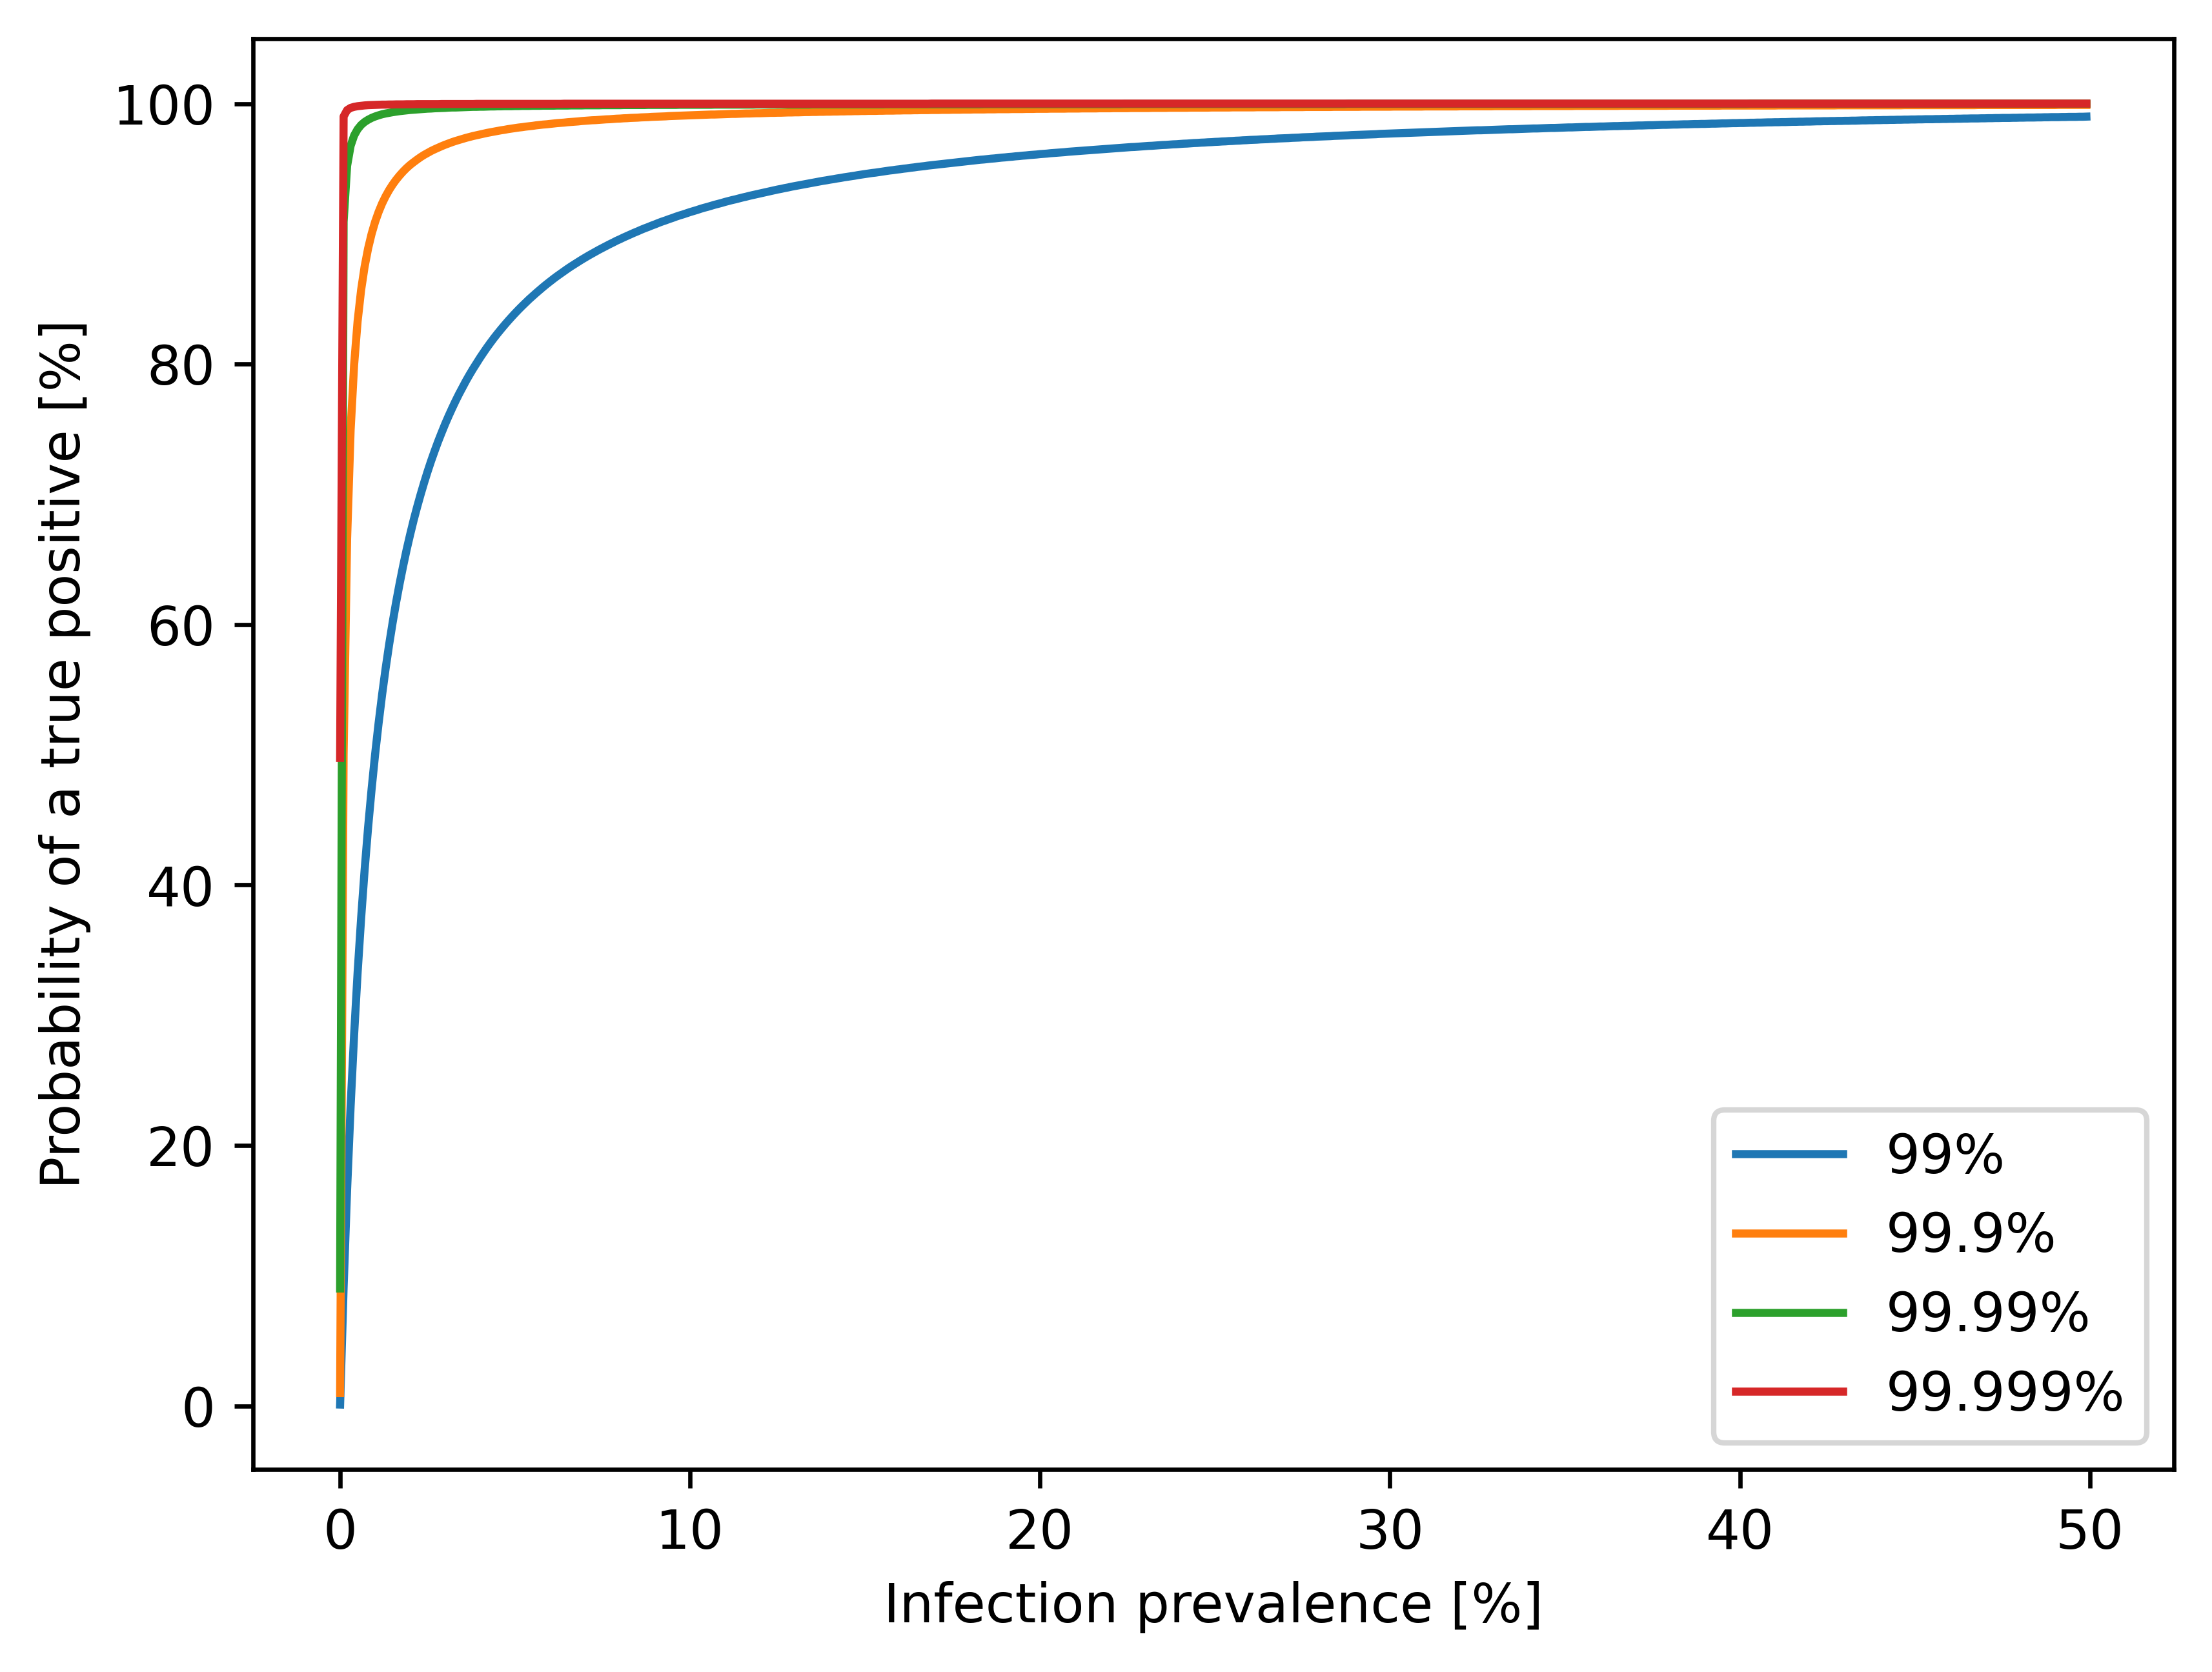

In [43]:
# Define our x values.
infratelist = []
for i in range(0, 500, 1):
    infratelist.append(i/1000 + 0.00001)
# Define our y values
yval = {}
for sp in [0.99,0.999,0.9999,0.99999]:
    vals = []
    for i in infratelist:
        vals.append(probtruepos(i,sp))
    yval[sp] = vals

infratepercent = []
for i in infratelist:
    infratepercent.append(i*100)

# Plot one curve per specificity value.
figure = plt.figure(dpi=600)
for sp in [0.99,0.999,0.9999,0.99999]:
    plt.plot(infratepercent,yval[sp])
plt.legend(labels=['99%', '99.9%', '99.99%', '99.999%'])
plt.ylabel('Probability of a true positive [%]')
plt.xlabel('Infection prevalence [%]')

Using a population of 10,000 again let's look at the most extreme examples (prevalence: 0.001% and 50%; specificity: 99% and 99.999%).
### 0.001% 99%
true positives = 0.99\*0.00001\*10000 = 0.099\
false positives = (1-0.99)\*(1-0.00001)\*10000 = 99.999\
P(TP) = 0.099/(99.999 + 0.099) => 0.0989%
### 0.001% 99.999%
true positives = 0.99\*0.00001\*10000 = 0.099\
false positives = (1-0.99999)\*(1-0.00001)\*10000 = 0.099999\
P(TP) = 0.099/(0.099999 + 0.099) => 49.75%
### 50% 99%
true positives = 0.99\*0.5\*10000 = 4950\
false positives = (1-0.99)\*(1-0.5)\*10000 = 50\
P(TP) = 4950/(50 + 4950) => 99%
### 50% 99.999%
true positives = 0.99\*0.5\*10000 = 4950\
false positives = (1-0.99999)\*(1-0.5)\*10000 = 0.05\
P(TP) = 4950/(0.05 + 4950) => 99.9989%

In other words, with higher infection prevalence the likelihood of the test being correct increases logarithmically because the infected population increases and with that does the true positive population (while the healthy population declines and therefore the population of false negatives). With increasing specificity the false negative population declines and thus the difference between the true positive population and the total positive population (i.e., the probability of a true positive increases).